# 01c - Interpolación de Hermite y Splines
---

# Librerías: **no olvidar correr esta celda**

In [1]:
import numpy as np #paquete para manejar arreglos
from matplotlib import pyplot as plt #para graficar

# https://numpy.org/doc/stable/reference/routines.polynomials.classes.html
from numpy.polynomial import Polynomial as Poly #para interpolar

# Detalle técnico no relevante
plt.rcParams["figure.figsize"] = (8,5) #tamaño de los gráficos: ancho x alto

---
# Interpolación de Hermite

## Hallar un polinomio $P$ de grado menor o igual a 4 que cumpla que:

$$P(0)=0, \ \ \ \ P(1)=2, \ \ \ \ P(3)=1, \ \ \ \ P'(3)=0, \ \ \ \ P''(3)=4$$


In [2]:
# Con coeficientes indeterminados:

# armar el sistema y resolverlo. Eso nos da los coeficientes del polinomio.
# p(x) = a + bx + cx**2 + dx**3 + ex**4 #en el orden en que los necesita Poly
# las cuentas para armar el sistema hay que hacerlas en papel.

#matrices del sistema
A = np.array([[1,0,0,0,0], [1,1,1,1,1], [1,3,9,27,81], [0,1,6,27,108], [0,0,2,18,108]])
b = np.array([0,2,1,0,4])

#resuelvo el sistema y obtengo los coeficientes del polinomio (en orden creciente de potencias de x)
coefs = np.linalg.solve(A,b)

# armar el polinomio de Hermite en base a los coeficientes obtenidos
pol_hermite = Poly(coefs)
print("Polinomio de Hermite:", pol_hermite)

# Verificar que el polinomio cumple las condiciones que nos piden
# print("p(0)=",pol_hermite(0))
# print("p(1)=",pol_hermite(1))
# print("p(3)=",pol_hermite(3))

# Para verificar las condiciones sobre las derivadas se puede usar deriv() para derivar polinomios
# pol_hermite_deriv1 = pol_hermite.deriv()
# print("")
# print("Derivada 1ra. del pol Hermite:", pol_hermite_deriv1)
# print("p'(3)=",pol_hermite_deriv1(3))

# pol_hermite_deriv2 = pol_hermite_deriv1.deriv()
# print("")
# print("Derivada 2da. del pol Hermite:", pol_hermite_deriv2)
# print("p''(3)=",pol_hermite_deriv2(3))

Polinomio de Hermite: 0.0 + 2.375·x + 0.29166667·x² - 0.83796296·x³ + 0.1712963·x⁴


---
---
# Interpolación por Splines cúbicos

## Librerías: **no olvidar correr esta celda**

In [3]:
import numpy as np #paquete para manejar arreglos
from matplotlib import pyplot as plt #para graficar

#para interpolar por splines
from scipy import interpolate
# https://docs.scipy.org/doc/scipy/reference/interpolate.html

# spline cúbico
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html


# Detalle técnico no relevante
plt.rcParams["figure.figsize"] = (10,7) #tamaño de los gráficos: ancho x alto

---
## Charlar un rato sobre interpolar por splines

- ### Diferencias / Ventajas / Desventajas respecto a Taylor e interp. polinomial
- ### Condiciones de borde para splines
- ### ¿Cómo hace el gráfico de un función Python para que parezca una línea continua, cuando en realidad tiene muchos puntos?
---

## Interpolar la función $f(x)=e^{(\cos(\pi x)+1)^2}$ con x entre -3 y 2, con Splines **Cúbicos**.
 - ### Usar nodos equiespaciados y variar la cantidad de subintervalos (por ejemplo 10, 20 y 30). Observar qué pasa a medida que aumenta la cantidad.
 - ### Graficar la función, los nodos y los Splines en un mismo gráfico.


Polinomio interpolador: 2.71828183 + 207.58648584·(0.2 + 0.4x) + 1070.11384269·(0.2 + 0.4x)² -
2056.60450028·(0.2 + 0.4x)³ - 12960.62152402·(0.2 + 0.4x)⁴ +
5660.68424829·(0.2 + 0.4x)⁵ + 49929.35680969·(0.2 + 0.4x)⁶ -
6092.71298739·(0.2 + 0.4x)⁷ - 72571.73954897·(0.2 + 0.4x)⁸ +
2307.84582856·(0.2 + 0.4x)⁹ + 34557.97121379·(0.2 + 0.4x)¹⁰


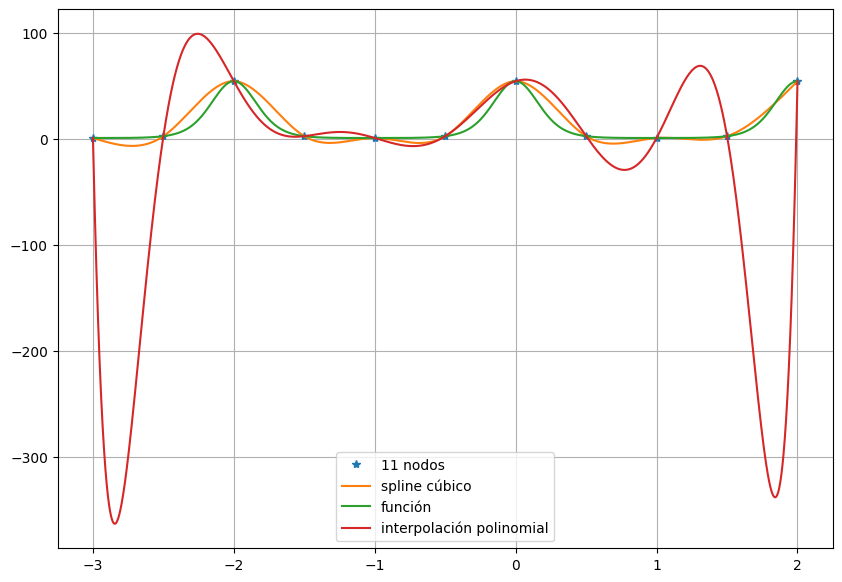

In [13]:
# definimos la función con la que construiremos la tabla de valores o malla a
# interpolar por splines
def func(x):
  y = np.exp( (np.cos(np.pi*x)+1)**2 )
  return y

# definimos inicio, fin, y cantidad de intervalos
a = -3
b = 2
cant_intervs =  12 # cantidad de intervalos. Probar con 10, 20, 30 y observar qué pasa.

# tabla de valores o malla a interpolar por splines
tabla_x = np.linspace(a,b,cant_intervs-1)  # cant de nodos = cant. intervalos + 1
tabla_y = func(tabla_x)

# COMENTARIO. Si la tabla viene dada por datos, la hacemos como antes en interp polinomial
# tabla_x = np.array( [...] )
# tabla_y = np.array( [...] )


# creamos el spline a partir de la malla: en este caso splines lineales
spline_cubico =  interpolate.CubicSpline(tabla_x, tabla_y, bc_type = "natural") #es derivada segunda = 0 en los bordes

#otras opciones de borde
# spline_cubico = interpolate.CubicSpline(vals_x_spline, vals_y_spline, bc_type = "not-a-knot") #default: "pega bien" los splines.
# spline_cubico = interpolate.CubicSpline(vals_x_spline, vals_y_spline, bc_type = "clamped") #derivada primera = 0 en los bordes.
# spline_cubico = interpolate.CubicSpline(vals_x_spline, vals_y_spline, bc_type = "periodic") #igual en los bordes (implica derivadas 1ra. y 2da. iguales en los bordes)

# con condiciones de borde a mano
# izq = -1
# der = 1
# spline_cubico = interpolate.CubicSpline(vals_x_spline, vals_y_spline, bc_type = ((1,izq),(1,der)))
# la sintaxis es (orden de la derivada, condición)


# graficamos función, splines y nodos
vals_x_graf = np.linspace(a,b,10000)
vals_y_spline_graf = spline_cubico(vals_x_graf)
vals_y_func_graf = func(vals_x_graf)

plt.plot(tabla_x, tabla_y, "*", label= f'{cant_intervs-1} nodos') #graficamos nodos
plt.plot(vals_x_graf, vals_y_spline_graf, label='spline cúbico') #graficamos el spline
plt.plot(vals_x_graf, vals_y_func_graf, label='función') #graficamos la función
plt.legend()
plt.grid()



# agregamos interpolación polinomial para comparar
# DESCOMENTAR TODO LO DE ABAJO Y VOLVER A CORRER ESTA CELDA, para comparar spline vs. interp polinomial
grado = len(tabla_x) - 1
pol_interp = Poly.fit(tabla_x, tabla_y, grado)

plt.plot(vals_x_graf, pol_interp(vals_x_graf), label="interpolación polinomial")
plt.legend()

#¡el polinomio interpolador es de grado muy grande! Y entonces tiene oscilaciones grandes
print("Polinomio interpolador:", pol_interp)

---
# **Ejercicio:** hacer el ejercicio 19 de la P1.

## Comentario sobre uso de splines para integración numérica.